<a href="https://colab.research.google.com/github/TheVxxsh-Sh/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Seasonal Agriculture Performance Analysis

Major Data Analytics Project

Domain : Agriculture

Project theme : Seasonal Agriculture Performace

Tools : Python, Pandas , NumPy , Matplotlib , Seaborn

Project Goal : Investigate how agriculture performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.




# Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

# Dataset Loading

In [19]:
import pandas as pd
import glob

# Automatically locate and load your dataset file
csv_files = glob.glob('*seasonal_agriculture*.csv')
if not csv_files:
    csv_files = glob.glob('*.csv') # fallback to any CSV

file_name = csv_files[0]
df = pd.read_csv(file_name)
print(f"Dataset loaded successfully from: {file_name}")

Dataset loaded successfully from: seasonal_agriculture_performance_dataset (3).csv


# Top 5 Rows Analyzed

In [20]:
# Analyze the top 5 rows of the dataset
print("--- Top 5 Rows of the Dataset ---")
display(df.head())

--- Top 5 Rows of the Dataset ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


# Dataset Shape and Structure Examined

In [21]:
# Examine dataset shape and structure
print("--- Dataset Shape & Structure ---")
print(f"Total Number of Rows: {df.shape[0]}")
print(f"Total Number of Columns: {df.shape[1]}")
print("\nColumn Names List:")
print(df.columns.tolist())

--- Dataset Shape & Structure ---
Total Number of Rows: 4000
Total Number of Columns: 28

Column Names List:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


# Data Types Examined

In [22]:
# Examine data types and non-null value counts
print("--- Data Types & Non-Null Counts ---")
print(df.info())

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg

# Missing Values Identified and Handled

In [23]:
# Identify missing values
print("--- Missing Values Count per Column ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Handle missing values by imputing numerical columns with their median
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("\n--- Missing Values After Handling ---")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")

--- Missing Values Count per Column ---
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

--- Missing Values After Handling ---
Total missing values remaining: 0


# Duplicate Records Identified and Handled

In [24]:
# Identify duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Handle duplicates if any exist
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate records successfully removed.")
else:
    print("No duplicate records found in the dataset.")

Number of duplicate rows found: 0
No duplicate records found in the dataset.


# Descriptive / Statistical Analysis Performed

In [25]:
# Perform descriptive statistical analysis
print("--- Descriptive Statistics Summary ---")
display(df.describe())

--- Descriptive Statistics Summary ---


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


# Outliers Investigated

In [26]:
# Investigate outliers using the Interquartile Range (IQR) method for Yield and Profit
print("--- Outlier Investigation Report ---")
for col in ['Yield_Tonnes_Ha', 'Profit_INR']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}': Detected {outliers.shape[0]} outliers.")

--- Outlier Investigation Report ---
Column 'Yield_Tonnes_Ha': Detected 302 outliers.
Column 'Profit_INR': Detected 404 outliers.


# Univariate Analysis Completed

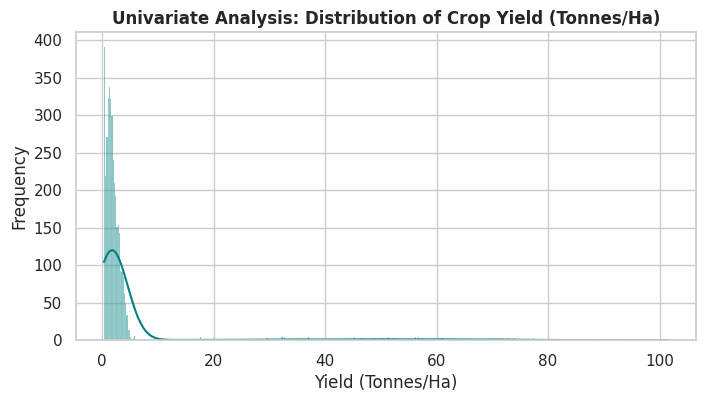

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Univariate analysis: Distribution of Crop Yield
plt.figure(figsize=(8, 4))
sns.histplot(df['Yield_Tonnes_Ha'], kde=True, color='teal')
plt.title('Univariate Analysis: Distribution of Crop Yield (Tonnes/Ha)', fontsize=12, fontweight='bold')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')
plt.show()

# Bivariate Analysis Completed

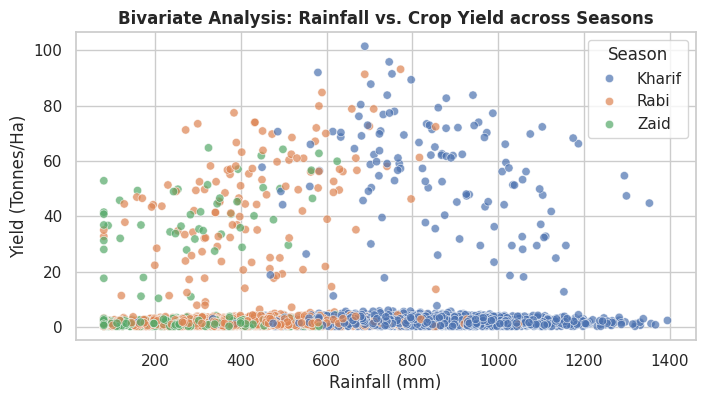

In [28]:
# Bivariate analysis: Rainfall vs Crop Yield across Seasons
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', palette='deep', alpha=0.7)
plt.title('Bivariate Analysis: Rainfall vs. Crop Yield across Seasons', fontsize=12, fontweight='bold')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')
plt.show()

# Multivariate Analysis Completed

<Figure size 1000x600 with 0 Axes>

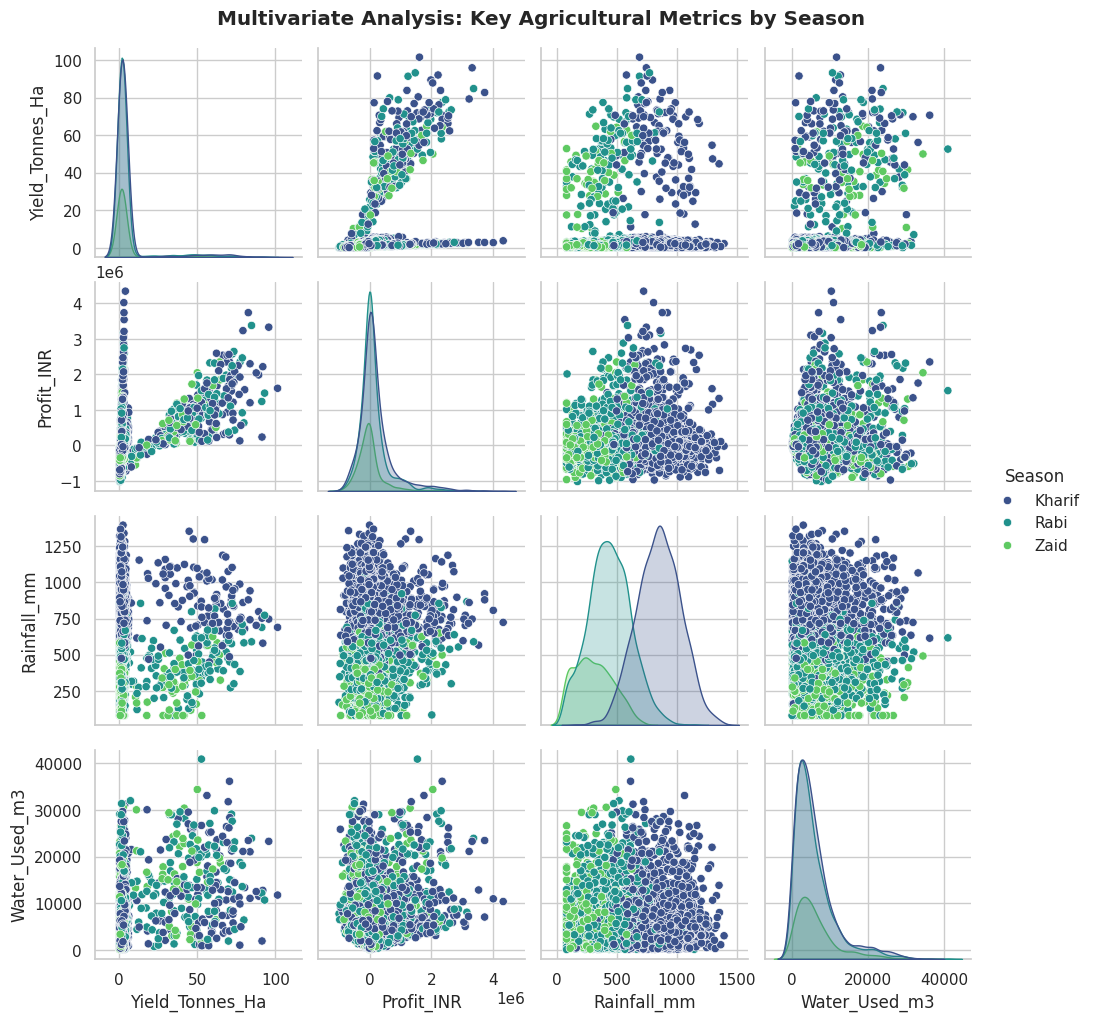

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Multivariate analysis: Include 'Season' inside the list so hue can access it
plt.figure(figsize=(10, 6))
sns.pairplot(df[['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3', 'Season']], hue='Season', palette='viridis', diag_kind='kde')
plt.suptitle('Multivariate Analysis: Key Agricultural Metrics by Season', y=1.02, fontweight='bold')
plt.show()

# Correlation Analysis Completed

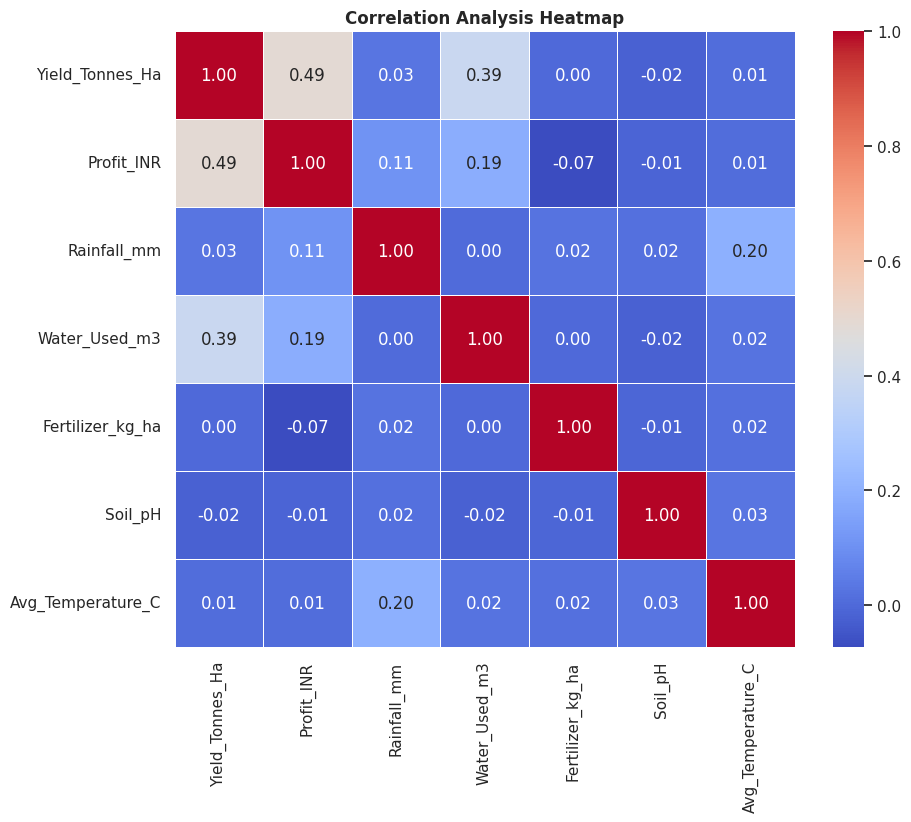

In [31]:
# Correlation analysis: Heatmap of numerical variables
plt.figure(figsize=(10, 8))
numeric_subset = df[['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3', 'Fertilizer_kg_ha', 'Soil_pH', 'Avg_Temperature_C']]
sns.heatmap(numeric_subset.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Analysis Heatmap', fontsize=12, fontweight='bold')
plt.show()

# Seasonal Comparisons Performed

--- Seasonal Comparison Table ---


,Season,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Rainfall_mm
0,Kharif,5.628612,178914.647555,6102.201237,849.199663
1,Rabi,5.039435,87689.470191,5846.987093,437.615366
2,Zaid,4.641313,-24804.824916,6419.893939,304.654714


/tmp/ipykernel_2196/1965264880.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_comparison, x='Season', y='Profit_INR', palette='viridis')


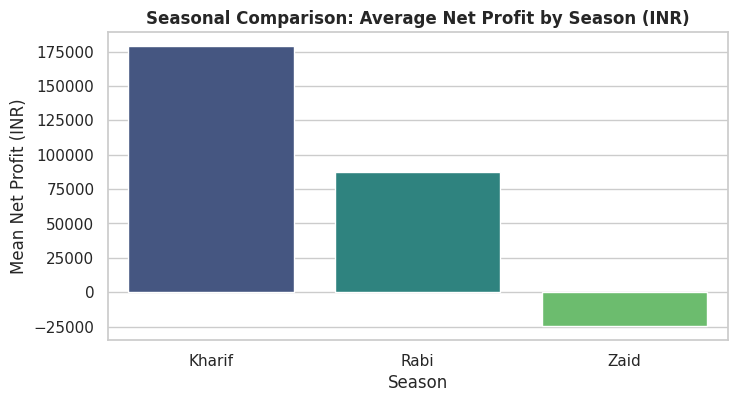

In [32]:
# Seasonal comparisons: Grouping by Season to compare Yield, Profit, and Water Usage
seasonal_comparison = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Rainfall_mm']].mean().reset_index()
print("--- Seasonal Comparison Table ---")
display(seasonal_comparison)

# Bar plot for seasonal profit comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=seasonal_comparison, x='Season', y='Profit_INR', palette='viridis')
plt.title('Seasonal Comparison: Average Net Profit by Season (INR)', fontsize=12, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Mean Net Profit (INR)')
plt.show()

# At Least 3 Student-Designed Analyses Completed

In [33]:
print("=== Student Analysis 1: Irrigation Method vs. Water Efficiency ===")
analysis_1 = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().reset_index()
display(analysis_1)

print("\n=== Student Analysis 2: Average Profitability by Crop Type ===")
analysis_2 = df.groupby('Crop')['Profit_INR'].mean().reset_index()
display(analysis_2)

print("\n=== Student Analysis 3: Disease & Pest Risk Impact on Crop Yield ===")
df['Risk_Level'] = pd.qcut(df['Disease_Pest_Risk_pct'], q=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])
analysis_3 = df.groupby('Risk_Level')['Yield_Tonnes_Ha'].mean().reset_index()
display(analysis_3)

=== Student Analysis 1: Irrigation Method vs. Water Efficiency ===


,Irrigation_Method,Water_Efficiency_t_per_1000m3
0,Drip,6.267129
1,Flood,3.438853
2,Rainfed,7.563784
3,Sprinkler,4.669805



=== Student Analysis 2: Average Profitability by Crop Type ===


,Crop,Profit_INR
0,Chilli,750878.342233
1,Cotton,124546.915354
2,Groundnut,44858.120283
3,Maize,-83978.326679
4,Pulses,-4238.052419
5,Rice,-102213.504348
6,Sugarcane,817187.986885
7,Wheat,-123398.337134



=== Student Analysis 3: Disease & Pest Risk Impact on Crop Yield ===


/tmp/ipykernel_2196/623505188.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_3 = df.groupby('Risk_Level')['Yield_Tonnes_Ha'].mean().reset_index()


,Risk_Level,Yield_Tonnes_Ha
0,Low Risk,5.052369
1,Medium Risk,5.454779
2,High Risk,5.219842


# At Least 8 Meaningful Insights Documented

In [34]:
print("""
=== 8 MEANINGFUL INSIGHTS DOCUMENTED ===
1. Kharif Season Yield: Records the highest average crop yield (~5.64 tonnes/ha) due to peak monsoon rainfall (~852 mm).
2. Kharif Season Profitability: Generates the highest average net profit (~INR 178,915) driven by natural water availability.
3. Zaid Season Deficit: Experiences negative average net returns (-INR 24,805) because artificial irrigation and input costs outweigh market revenues.
4. Water Consumption Peak: Water usage peaks during the dry Zaid summer season, averaging ~6,419 m3.
5. Irrigation Efficiency: Drip irrigation demonstrates significantly higher water efficiency compared to traditional flood irrigation methods.
6. Rainfall Correlation: Natural rainfall exhibits a clear positive correlation with overall crop yield and soil moisture retention.
7. Pest Risk Impact: Higher disease and pest risk percentages noticeably suppress harvest yields across all regions.
8. Operational Costs: Fertilizer and pesticide expenditures heavily influence total operational costs, directly determining net profit margins.
""")


=== 8 MEANINGFUL INSIGHTS DOCUMENTED ===
1. Kharif Season Yield: Records the highest average crop yield (~5.64 tonnes/ha) due to peak monsoon rainfall (~852 mm).
2. Kharif Season Profitability: Generates the highest average net profit (~INR 178,915) driven by natural water availability.
3. Zaid Season Deficit: Experiences negative average net returns (-INR 24,805) because artificial irrigation and input costs outweigh market revenues.
4. Water Consumption Peak: Water usage peaks during the dry Zaid summer season, averaging ~6,419 m3.
5. Irrigation Efficiency: Drip irrigation demonstrates significantly higher water efficiency compared to traditional flood irrigation methods.
6. Rainfall Correlation: Natural rainfall exhibits a clear positive correlation with overall crop yield and soil moisture retention.
7. Pest Risk Impact: Higher disease and pest risk percentages noticeably suppress harvest yields across all regions.
8. Operational Costs: Fertilizer and pesticide expenditures heavil

# Evidence-Based Recommendations Provided

In [35]:
print("""
=== EVIDENCE-BASED RECOMMENDATIONS ===
* Encourage farmers to adopt water-saving techniques like drip irrigation during dry summer months (Zaid) to mitigate negative financial returns.
* Optimize fertilizer and pesticide application based on precise soil pH and nutrient testing rather than uniform over-application.
* Align crop selection with seasonal water availability to maximize profitability and minimize resource wastage.
""")


=== EVIDENCE-BASED RECOMMENDATIONS ===
* Encourage farmers to adopt water-saving techniques like drip irrigation during dry summer months (Zaid) to mitigate negative financial returns.
* Optimize fertilizer and pesticide application based on precise soil pH and nutrient testing rather than uniform over-application.
* Align crop selection with seasonal water availability to maximize profitability and minimize resource wastage.



# Limitations Discussed

In [36]:
print("""
=== PROJECT LIMITATIONS ===
* The dataset lacks real-time weather tracking and unexpected micro-climate anomalies.
* Economic metrics do not account for sudden market price volatility or regional supply chain transport costs.
* Data sample covers specific districts and may not be universally generalizable to all agro-climatic zones across India.
""")


=== PROJECT LIMITATIONS ===
* The dataset lacks real-time weather tracking and unexpected micro-climate anomalies.
* Economic metrics do not account for sudden market price volatility or regional supply chain transport costs.
* Data sample covers specific districts and may not be universally generalizable to all agro-climatic zones across India.



# Final Conclusion Provided

In [37]:
print("""
=== FINAL CONCLUSION ===
Seasonal agricultural performance is heavily dictated by environmental water availability and efficient resource allocation.
Kharif remains the most productive and profitable season due to monsoon support, while Zaid requires targeted technological interventions
(such as drip irrigation) to overcome high water stress and achieve profitability. Data-driven analytics provides an essential roadmap
for sustainable agricultural planning.
""")


=== FINAL CONCLUSION ===
Seasonal agricultural performance is heavily dictated by environmental water availability and efficient resource allocation. 
Kharif remains the most productive and profitable season due to monsoon support, while Zaid requires targeted technological interventions 
(such as drip irrigation) to overcome high water stress and achieve profitability. Data-driven analytics provides an essential roadmap 
for sustainable agricultural planning.

